# Oral Cancer Prediction

## 1. Load Data

In [21]:
# 1. Load Data
import pandas as pd

# Path to merged labeled data
data_path = '../data/processed/merged_with_labels.csv'

# Load the data
df = pd.read_csv(data_path)

# Separate features and label
X = df.drop(columns=['label'])
y = df['label']

# Display shape and preview
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4220, 17)


,race,primary_therapy_outcome_success,anatomic_neoplasm_subdivision,kras_gene_analysis_performed,lymphatic_invasion,preoperative_pretreatment_cea_level,history_of_colon_polyps,circumferential_resection_margin,colon_polyps_present,braf_gene_analysis_performed,synchronous_colon_cancer_present,loss_expression_of_mismatch_repair_proteins_by_ihc,lymphnodes_positive_percent,margin_status,additional_radiation_therapy,planned_surgery_status,label
0,-1.569171,-0.198791,-0.803536,-0.187959,-0.388739,-0.061356,3.036102,-0.087875,4.264014,-0.132677,-0.131749,5.191052,-0.585376,-0.013316,-0.139893,0.049995,0
1,-1.569171,6.870566,-1.346431,-0.187959,-0.388739,-0.066996,-0.329370,2.109364,4.264014,-0.132677,7.590198,5.191052,-0.426484,-0.013316,-0.139893,0.049995,1
2,-1.569171,-0.198791,-0.667812,-0.187959,-0.388739,-0.061356,-0.329370,0.888676,-0.234521,-0.132677,-0.131749,5.191052,-0.585376,-0.013316,-0.139893,0.049995,0
3,-1.569171,4.514114,-1.346431,-0.187959,-0.388739,2.508615,-0.329370,-0.087875,4.264014,-0.132677,-0.131749,-0.192639,-0.585376,-0.013316,-0.139893,0.049995,1
4,-1.569171,4.514114,1.910939,-0.187959,2.572417,-0.064129,-0.329370,-0.087875,4.264014,-0.132677,-0.131749,-0.192639,3.170239,-0.013316,-0.139893,0.049995,1


## 2. Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

# Stratified 90/10 split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)

# Confirm shapes and label distribution
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain label distribution:\n", y_train.value_counts(normalize=True))
print("\nTest label distribution:\n", y_test.value_counts(normalize=True))

Train shape: (3798, 16)
Test shape: (422, 16)

Train label distribution:
 label
0    0.66851
1    0.33149
Name: proportion, dtype: float64

Test label distribution:
 label
0    0.668246
1    0.331754
Name: proportion, dtype: float64


## 3. Model: Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    max_depth=None,  # let trees grow until pure
    class_weight='balanced',  # handle class imbalance
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # for ROC & PR-AUC

## 4. Evaluation Metrics

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       282
           1       0.90      0.88      0.89       140

    accuracy                           0.93       422
   macro avg       0.92      0.92      0.92       422
weighted avg       0.93      0.93      0.93       422


AUROC: 0.9714
PR-AUC: 0.9588


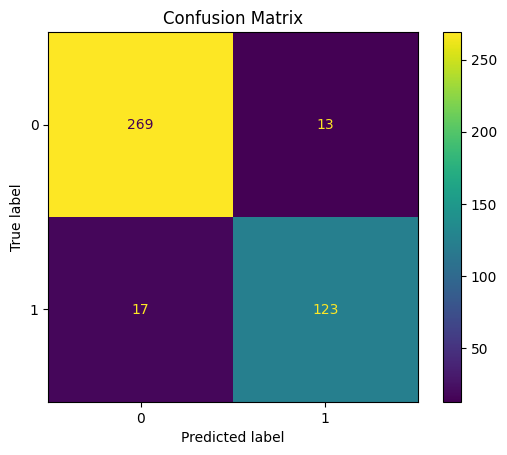

In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)
import matplotlib.pyplot as plt
import json

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# AUROC & PR-AUC
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"\nAUROC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

# Confusion Matrix Plot
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.savefig("../outputs/confusion_matrix.png")
plt.show()

# Save metrics to JSON
metrics = {
    "roc_auc": round(roc_auc, 4),
    "pr_auc": round(pr_auc, 4),
    "classification_report": classification_report(y_test, y_pred, output_dict=True)
}

with open("../outputs/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=4)

## 5. Visualizations: Confusion Matrix & ROC

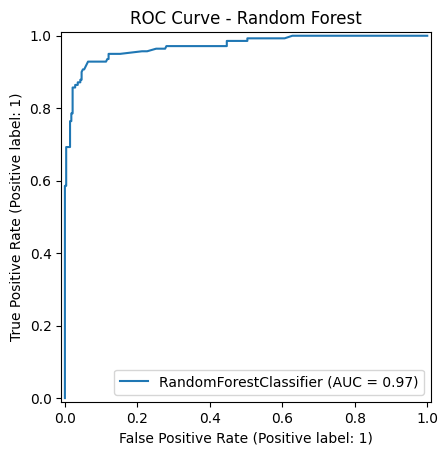

In [17]:
from sklearn.metrics import RocCurveDisplay

roc_display = RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.savefig("../outputs/roc_curve.png")
plt.show()

## 6. SHAP Explainability

SHAP returned a single array. Using directly.


<Figure size 640x480 with 0 Axes>

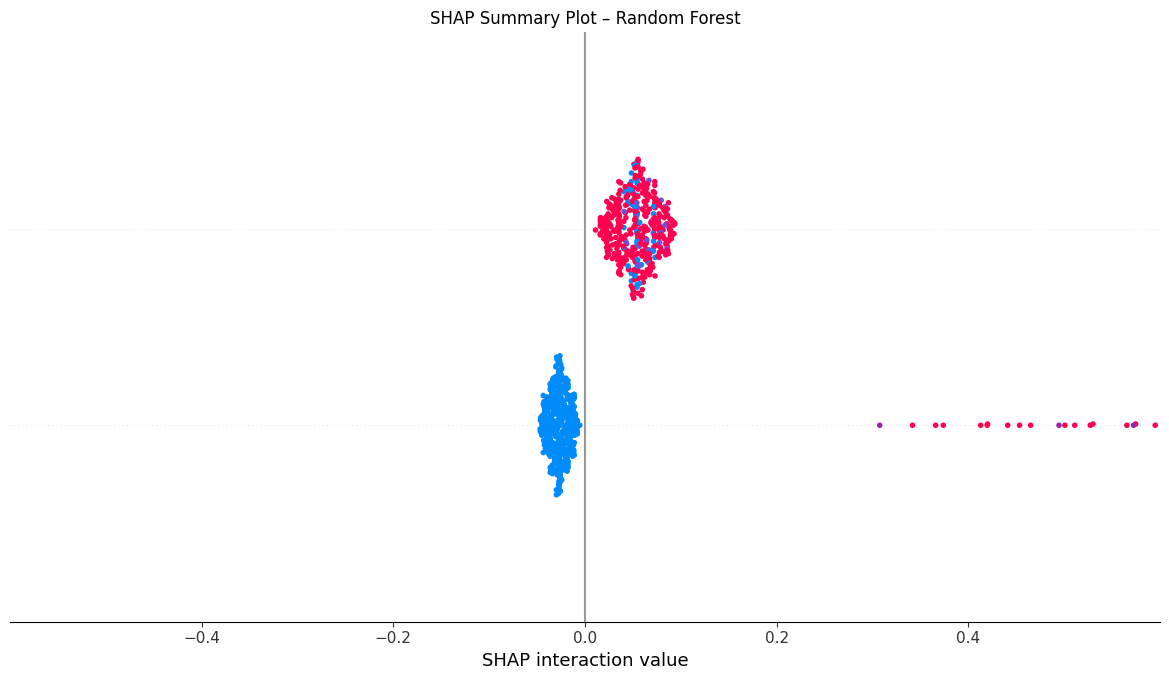

X_test shape: (422, 16)
SHAP values shape: (422, 16, 2)


In [18]:
import shap
import matplotlib.pyplot as plt

# 1️⃣ Create the SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# 2️⃣ Compute SHAP values
shap_values = explainer.shap_values(X_test)

# 3️⃣ Detect correct format
if isinstance(shap_values, list) and len(shap_values) == 2:
    print("SHAP returned a list of arrays (per class). Using class 1 (cancer).")
    shap_to_plot = shap_values[1]
else:
    print("SHAP returned a single array. Using directly.")
    shap_to_plot = shap_values

# 4️⃣ Plot summary
shap.summary_plot(shap_to_plot, X_test, show=False)
plt.title("SHAP Summary Plot – Random Forest")
plt.savefig("../outputs/shap_summary_plot.png", bbox_inches="tight")
plt.show()
print("X_test shape:", X_test.shape)
print("SHAP values shape:", shap_to_plot.shape)


## 7. Save Model & Metrics

In [19]:
import joblib
import json

# Save trained model
joblib.dump(rf_model, "../models/rf_model.pkl")
print("Model saved to models/rf_model.pkl ✅")

model_info = {
    "model_type": "RandomForestClassifier",
    "date": "2025-05-11",
    "features_used": list(X_test.columns),
    "n_features": X_test.shape[1],
    "test_samples": X_test.shape[0],
    "roc_auc": round(roc_auc, 4),
    "pr_auc": round(pr_auc, 4)
}

with open("../models/best_model_metadata.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model metadata saved ✅")


Model saved to models/rf_model.pkl ✅
Model metadata saved ✅
